In [2]:
import pandas as pd
import numpy as np
import regex as re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, fbeta_score, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve


In [3]:
dfweek = pd.read_csv('../data/raw/week_approach.csv')
dfweek.head(20)

,nr. sessions,nr. rest days,total kms,max km one day,total km Z3-Z4-Z5-T1-T2,"nr. tough sessions (effort in Z5, T1 or T2)",nr. days with interval session,total km Z3-4,max km Z3-4 one day,total km Z5-T1-T2,...,max training success.2,avg recovery.2,min recovery.2,max recovery.2,Athlete ID,injury,rel total kms week 0_1,rel total kms week 0_2,rel total kms week 1_2,Date
0,5.0,2.0,22.2,16.4,11.8,1.0,2.0,10.0,10.0,0.6,...,0.0,0.18,0.16,0.20,0,0,0.718447,1.378882,1.919255,0
1,5.0,2.0,21.6,16.4,11.7,1.0,2.0,10.0,10.0,0.5,...,0.0,0.18,0.16,0.20,0,0,0.683544,1.018868,1.490566,1
2,5.0,2.0,21.6,16.4,11.7,1.0,2.0,10.0,10.0,0.5,...,0.0,0.17,0.16,0.18,0,0,0.683544,1.018868,1.490566,2
3,5.0,2.0,21.6,16.4,11.7,1.0,2.0,10.0,10.0,0.5,...,0.0,0.18,0.16,0.18,0,0,0.683544,1.018868,1.490566,3
4,6.0,1.0,39.2,17.6,18.9,1.0,3.0,17.2,10.0,0.5,...,0.0,0.17,0.16,0.18,0,0,2.202247,1.361111,0.618056,4
5,6.0,1.0,39.2,17.6,18.9,1.0,3.0,17.2,10.0,0.5,...,0.0,0.17,0.16,0.18,0,0,2.202247,1.361111,0.618056,5
6,6.0,1.0,33.3,17.6,15.4,1.0,3.0,13.7,7.2,0.5,...,0.0,0.17,0.16,0.18,0,0,1.500000,1.077670,0.718447,6
7,5.0,2.0,33.3,17.6,15.4,1.0,3.0,13.7,7.2,0.5,...,0.0,0.17,0.16,0.18,0,0,1.500000,1.077670,0.718447,7
8,5.0,2.0,32.9,17.6,15.5,0.0,3.0,14.3,7.2,0.0,...,0.0,0.17,0.16,0.18,0,0,1.523148,1.041139,0.683544,8
9,5.0,2.0,32.9,17.6,15.5,0.0,3.0,14.3,7.2,0.0,...,0.0,0.17,0.16,0.18,0,0,1.523148,1.041139,0.683544,9


In [4]:
dfday = pd.read_csv('../data/raw/day_approach.csv')
dfday.head(20)

,nr. sessions,total km,km Z3-4,km Z5-T1-T2,km sprinting,strength training,hours alternative,perceived exertion,perceived trainingSuccess,perceived recovery,...,km Z5-T1-T2.6,km sprinting.6,strength training.6,hours alternative.6,perceived exertion.6,perceived trainingSuccess.6,perceived recovery.6,Athlete ID,injury,Date
0,1.0,5.8,0.0,0.6,1.2,0.0,0.00,0.11,0.00,0.18,...,0.0,0.0,0.0,1.0,0.10,0.00,0.15,0,0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.00,-0.01,-0.01,-0.01,...,0.5,1.2,0.0,0.0,0.10,0.00,0.17,0,0,1
2,1.0,0.0,0.0,0.0,0.0,1.0,0.00,0.10,0.00,0.17,...,0.0,0.0,0.0,0.0,-0.01,-0.01,-0.01,0,0,2
3,0.0,0.0,0.0,0.0,0.0,0.0,0.00,-0.01,-0.01,-0.01,...,0.0,0.0,1.0,0.0,0.10,0.00,0.17,0,0,3
4,1.0,0.0,0.0,0.0,0.0,0.0,1.08,0.08,0.00,0.18,...,0.0,0.0,0.0,0.0,0.11,0.00,0.17,0,0,4
5,1.0,16.4,10.0,0.0,0.0,1.0,0.00,0.11,0.00,0.17,...,0.0,0.0,0.0,1.0,0.08,0.00,0.17,0,0,5
6,1.0,0.0,0.0,0.0,0.0,0.0,1.00,0.10,0.00,0.15,...,0.0,0.0,0.0,0.0,0.09,0.00,0.18,0,0,6
7,1.0,5.2,0.0,0.5,1.2,0.0,0.00,0.10,0.00,0.17,...,0.0,0.0,0.0,0.0,-0.01,-0.01,-0.01,0,0,7
8,0.0,0.0,0.0,0.0,0.0,0.0,0.00,-0.01,-0.01,-0.01,...,0.0,1.2,0.0,0.0,0.11,0.00,0.18,0,0,8
9,1.0,0.0,0.0,0.0,0.0,1.0,0.00,0.10,0.00,0.17,...,0.0,0.0,0.0,0.0,-0.01,-0.01,-0.01,0,0,9


In [5]:
dfweek.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42798 entries, 0 to 42797
Data columns (total 72 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   nr. sessions                                   42798 non-null  float64
 1   nr. rest days                                  42798 non-null  float64
 2   total kms                                      42798 non-null  float64
 3   max km one day                                 42798 non-null  float64
 4   total km Z3-Z4-Z5-T1-T2                        42798 non-null  float64
 5   nr. tough sessions (effort in Z5, T1 or T2)    42798 non-null  float64
 6   nr. days with interval session                 42798 non-null  float64
 7   total km Z3-4                                  42798 non-null  float64
 8   max km Z3-4 one day                            42798 non-null  float64
 9   total km Z5-T1-T2                              427

In [6]:
dfday.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42766 entries, 0 to 42765
Data columns (total 73 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   nr. sessions                 42766 non-null  float64
 1   total km                     42766 non-null  float64
 2   km Z3-4                      42766 non-null  float64
 3   km Z5-T1-T2                  42766 non-null  float64
 4   km sprinting                 42766 non-null  float64
 5   strength training            42766 non-null  float64
 6   hours alternative            42766 non-null  float64
 7   perceived exertion           42766 non-null  float64
 8   perceived trainingSuccess    42766 non-null  float64
 9   perceived recovery           42766 non-null  float64
 10  nr. sessions.1               42766 non-null  float64
 11  total km.1                   42766 non-null  float64
 12  km Z3-4.1                    42766 non-null  float64
 13  km Z5-T1-T2.1   

# Cleaning

# Drop subjective features
Percieved exertion and similar features will not be present in the user data and as such should not be present in the training data. While there is some capacity in gamin to track strength workouts, that will also be dropped as it doesn't seem to be common practice among runners to track it. It can possibly be added at a later date. whether a session is sprinting or intervals is also untracked in garmin and will need to be dropped.

In [7]:
dfday.drop(list(dfday.filter(regex = 'perceived|sprinting|strength')), axis = 1, inplace = True)
dfday.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42766 entries, 0 to 42765
Data columns (total 38 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   nr. sessions         42766 non-null  float64
 1   total km             42766 non-null  float64
 2   km Z3-4              42766 non-null  float64
 3   km Z5-T1-T2          42766 non-null  float64
 4   hours alternative    42766 non-null  float64
 5   nr. sessions.1       42766 non-null  float64
 6   total km.1           42766 non-null  float64
 7   km Z3-4.1            42766 non-null  float64
 8   km Z5-T1-T2.1        42766 non-null  float64
 9   hours alternative.1  42766 non-null  float64
 10  nr. sessions.2       42766 non-null  float64
 11  total km.2           42766 non-null  float64
 12  km Z3-4.2            42766 non-null  float64
 13  km Z5-T1-T2.2        42766 non-null  float64
 14  hours alternative.2  42766 non-null  float64
 15  nr. sessions.3       42766 non-null 

In [8]:
dfweek.drop(list(dfweek.filter(regex = 'recovery|training success|exertion|interval|strength')), axis = 1, inplace = True)
dfweek.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42798 entries, 0 to 42797
Data columns (total 39 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   nr. sessions                                   42798 non-null  float64
 1   nr. rest days                                  42798 non-null  float64
 2   total kms                                      42798 non-null  float64
 3   max km one day                                 42798 non-null  float64
 4   total km Z3-Z4-Z5-T1-T2                        42798 non-null  float64
 5   nr. tough sessions (effort in Z5, T1 or T2)    42798 non-null  float64
 6   total km Z3-4                                  42798 non-null  float64
 7   max km Z3-4 one day                            42798 non-null  float64
 8   total km Z5-T1-T2                              42798 non-null  float64
 9   max km Z5-T1-T2 one day                        427

In [9]:
dfday['Athlete ID'].nunique()

74

In [10]:
dfday['Date'].nunique()

2614

# Exploring

### Looking at an individual Athlete over time
to really get a better sense of what is contained in the dataset, I want to create some visualisations of what various features look like over time for a given athlete, specifically at the daily count. for simplicity I'll look at only the data over two years.

In [11]:
Athlete_investigate = dfday[dfday['Athlete ID'] == 30].head(2000)

Want to look at data on a daily scale here just for visualisation, so lagged values will be removed

In [12]:
Athlete_investigate.drop(list(Athlete_investigate.filter(regex = r'\.[1-6]$')), axis = 1, inplace = True)

In [13]:
Athlete_investigate.head(20)

,nr. sessions,total km,km Z3-4,km Z5-T1-T2,hours alternative,Athlete ID,injury,Date
18242,0.0,0.0,0.0,0.0,0.0,30,0,0
18243,1.0,2.5,0.0,0.0,0.0,30,0,1
18244,0.0,0.0,0.0,0.0,0.0,30,0,2
18245,1.0,3.7,0.0,0.0,0.0,30,0,3
18246,0.0,0.0,0.0,0.0,0.0,30,0,4
18247,0.0,0.0,0.0,0.0,0.0,30,0,5
18248,0.0,0.0,0.0,0.0,0.0,30,0,6
18249,0.0,0.0,0.0,0.0,0.0,30,0,7
18250,1.0,4.0,0.0,0.0,0.0,30,0,8
18251,0.0,0.0,0.0,0.0,0.0,30,0,9


In [14]:
Athlete_investigate[Athlete_investigate['km Z5-T1-T2']!= 0]


,nr. sessions,total km,km Z3-4,km Z5-T1-T2,hours alternative,Athlete ID,injury,Date


How many injuries did they sustain in the time period? We may need to expand the time period if they don't get injured at all. But annual injury rate is like 75% so I'm hopeful

In [15]:
Athlete_investigate[Athlete_investigate['injury']==1]

,nr. sessions,total km,km Z3-4,km Z5-T1-T2,hours alternative,Athlete ID,injury,Date


 Ouch!
I think this makes this user ideal to investigate. Research tells me that one of the main predictors of injury is historical injury, so this pattern whereby the athlete has no injuries for the first 300 days and then 7 in a span of just over 200 days is to be expected. The data do not unfortunately tell us if this is the same injury reoccuring, a three week span before and after each injury was required by the data collectors in Lovdal 2021 to define an injury event

>Injuries can be extracted from the so-called “flags” in the
training log. These flags are defined as “unable to complete thescheduled session due to injury.” They cover both cases where an
athlete starts a session but interrupts it due to injury, and cases
where the athlete skips the session due to injury.  
>In our data set, injuries are reflected by all records flagged
with injury from the training log, whereby it was required that
the athletes were training injury free 3 weeks prior to the session
flagged with injury. For the healthy events, we demanded that
the athlete is fully fit 3 weeks before and 3 weeks after the event
day. Moreover, events that contained missing or anomalous data
were removed from our data set.  
>Finally, injury events shortly following (within 3 wk of) a new
injury have been filtered out, as they are considered to correspond to
the same injury


Visually, it might be valuable to compute rolling averages. 

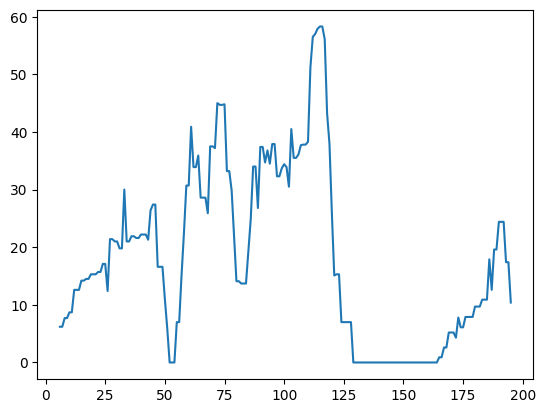

In [16]:
Athlete_investigate['weekvolume'] = Athlete_investigate['total km'].rolling(window=7).sum()
plt.plot(Athlete_investigate['Date'],Athlete_investigate['weekvolume'])

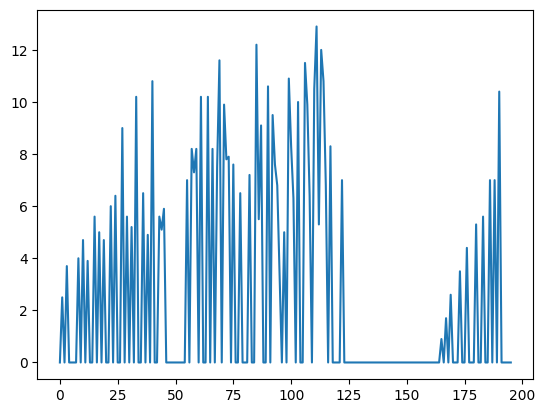

In [17]:
plt.plot(Athlete_investigate['Date'], Athlete_investigate['total km'])

In [18]:
Athlete_investigate['Date'].nunique()

196

In [19]:
Athlete_investigate.shape

(196, 9)

### Distribution of events
looking at amount of events per athlete and per date, to get a feel of what the overall dataset represents. The lowest 

In [20]:
events_per_athlete = pd.DataFrame(dfday['Athlete ID'].value_counts())
events_per_athlete

,count
Athlete ID,
32,1791
20,1723
22,1478
43,1471
23,1393
...,...
11,154
39,130
15,126


In [21]:
# for each athlete, how many injury = 0 are there, and how many injury = 1
injury_per_athlete = pd.DataFrame(dfday.groupby('Athlete ID')['injury'].value_counts())
injury_per_athlete = injury_per_athlete.unstack().fillna(0)
injury_per_athlete.columns = ['injury_0','injury_1']
i = 0
for index, row in injury_per_athlete.iterrows():
    if row['injury_1'] == 0:
        i += 1      
print(i) 

11


In [22]:
events_per_date = pd.DataFrame(dfday['Date'].value_counts())
events_per_date
plt.hist(events_per_date['Date'],bins=72)

KeyError: 'Date'

In [23]:
dfday.head()

,nr. sessions,total km,km Z3-4,km Z5-T1-T2,hours alternative,nr. sessions.1,total km.1,km Z3-4.1,km Z5-T1-T2.1,hours alternative.1,...,km Z5-T1-T2.5,hours alternative.5,nr. sessions.6,total km.6,km Z3-4.6,km Z5-T1-T2.6,hours alternative.6,Athlete ID,injury,Date
0,1.0,5.8,0.0,0.6,0.00,0.0,0.0,0.0,0.0,0.00,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0,0,0
1,0.0,0.0,0.0,0.0,0.00,1.0,0.0,0.0,0.0,0.00,...,0.0,1.0,1.0,5.2,0.0,0.5,0.0,0,0,1
2,1.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,...,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0,0,2
3,0.0,0.0,0.0,0.0,0.00,1.0,0.0,0.0,0.0,1.08,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,0,3
4,1.0,0.0,0.0,0.0,1.08,1.0,16.4,10.0,0.0,0.00,...,0.0,0.0,1.0,17.6,7.2,0.0,0.0,0,0,4


check to see just how correlated features are with each other

In [24]:
dfday.corr()

,nr. sessions,total km,km Z3-4,km Z5-T1-T2,hours alternative,nr. sessions.1,total km.1,km Z3-4.1,km Z5-T1-T2.1,hours alternative.1,...,km Z5-T1-T2.5,hours alternative.5,nr. sessions.6,total km.6,km Z3-4.6,km Z5-T1-T2.6,hours alternative.6,Athlete ID,injury,Date
nr. sessions,1.000000,0.596912,0.168277,0.176642,0.236287,0.262761,0.213076,0.080043,0.082879,0.075338,...,0.095351,0.056444,0.233104,0.198261,0.045521,0.071415,0.044208,-0.016132,0.024088,0.041084
total km,0.596912,1.000000,0.391130,0.328533,-0.173292,0.202723,0.332265,0.067742,0.028657,-0.061207,...,0.175339,-0.085848,0.186704,0.324134,0.087291,0.046730,-0.075958,-0.053750,0.015945,-0.020892
km Z3-4,0.168277,0.391130,1.000000,-0.086790,-0.058348,0.039958,0.084049,-0.048386,-0.074259,0.004551,...,0.071115,-0.020003,0.049913,0.065963,-0.003161,-0.051439,-0.021680,0.002224,0.000663,0.019508
km Z5-T1-T2,0.176642,0.328533,-0.086790,1.000000,-0.061606,0.080186,0.034156,-0.073659,-0.078071,-0.016082,...,0.194275,-0.022558,0.061082,0.048311,-0.024922,-0.037275,-0.035926,-0.027580,0.019899,-0.010745
hours alternative,0.236287,-0.173292,-0.058348,-0.061606,1.000000,0.073857,-0.067137,-0.014994,-0.036596,0.290018,...,-0.040996,0.238137,0.054669,-0.064205,0.001960,-0.026798,0.210298,-0.022488,-0.009111,0.049815
nr. sessions.1,0.262761,0.202723,0.039958,0.080186,0.073857,1.000000,0.597000,0.168479,0.176465,0.236931,...,0.066706,0.057759,0.258695,0.242642,0.069427,0.095757,0.057106,-0.016037,0.011690,0.040841
total km.1,0.213076,0.332265,0.084049,0.034156,-0.067137,0.597000,1.000000,0.390159,0.327636,-0.172484,...,0.106962,-0.095385,0.207020,0.436231,0.149604,0.176859,-0.083177,-0.054636,-0.009048,-0.021258
km Z3-4.1,0.080043,0.067742,-0.048386,-0.073659,-0.014994,0.168479,0.390159,1.000000,-0.086003,-0.057742,...,-0.025740,-0.025538,0.070528,0.168600,0.107412,0.071853,-0.019039,0.000315,-0.003363,0.018589
km Z5-T1-T2.1,0.082879,0.028657,-0.074259,-0.078071,-0.036596,0.176465,0.327636,-0.086003,1.000000,-0.062082,...,0.068362,-0.038815,0.081951,0.181657,0.023952,0.196453,-0.021402,-0.028582,0.000493,-0.010789
hours alternative.1,0.075338,-0.061207,0.004551,-0.016082,0.290018,0.236931,-0.172484,-0.057742,-0.062082,1.000000,...,-0.019838,0.239794,0.045798,-0.094185,-0.034705,-0.040463,0.235916,-0.021633,0.004842,0.049866


In [25]:
def checkforhighcorr(df,thresh=0.5):
    '''
    prints a list of features are highly correlated in a dataset based on a threshold

    Args: 
        df (DataFrame): the dataset we want to investigate correlation in
        thresh (float): a threshold at which the user considers correlation
        to be 'high', default 0.5
        
    '''
    highcorrlist = []
    for i in df:
        for j in df:
            local_corr = df[i].corr(df[j])
            if local_corr >thresh and i!=j:
                highcorrlist.append(f'{j} correlates with {i} value {local_corr}')
    import pprint
    pprint.pprint(highcorrlist)

In [26]:
checkforhighcorr(dfday)

['total km correlates with nr. sessions value 0.5969115577476987',
 'nr. sessions correlates with total km value 0.5969115577476987',
 'total km.1 correlates with nr. sessions.1 value 0.5970000847243292',
 'nr. sessions.1 correlates with total km.1 value 0.5970000847243292',
 'total km.2 correlates with nr. sessions.2 value 0.5971433655233465',
 'nr. sessions.2 correlates with total km.2 value 0.5971433655233465',
 'total km.3 correlates with nr. sessions.3 value 0.5968994973819781',
 'nr. sessions.3 correlates with total km.3 value 0.5968994973819781',
 'total km.4 correlates with nr. sessions.4 value 0.5966775896891141',
 'nr. sessions.4 correlates with total km.4 value 0.5966775896891141',
 'total km.5 correlates with nr. sessions.5 value 0.5973631119237455',
 'nr. sessions.5 correlates with total km.5 value 0.5973631119237455',
 'total km.6 correlates with nr. sessions.6 value 0.5964816195007668',
 'nr. sessions.6 correlates with total km.6 value 0.5964816195007668',
 'Date correla

In [27]:
checkforhighcorr(dfweek,0.8)

['max km one day correlates with total kms value 0.8684488053106159',
 'total kms.1 correlates with total kms value 0.8118897867874424',
 'total kms correlates with max km one day value 0.868448805310616',
 'max km Z3-4 one day correlates with total km Z3-4 value 0.9165835036930885',
 'total km Z3-4 correlates with max km Z3-4 one day value 0.9165835036930884',
 'max km Z5-T1-T2 one day correlates with total km Z5-T1-T2 value '
 '0.9261613198569565',
 'total km Z5-T1-T2 correlates with max km Z5-T1-T2 one day value '
 '0.9261613198569565',
 'total kms correlates with total kms.1 value 0.8118897867874425',
 'max km one day.1 correlates with total kms.1 value 0.8699921467794864',
 'total kms.2 correlates with total kms.1 value 0.8127673655044486',
 'total kms.1 correlates with max km one day.1 value 0.8699921467794863',
 'max km Z3-4 one day.1 correlates with total km Z3-4.1 value '
 '0.9164319993717517',
 'total km Z3-4.1 correlates with max km Z3-4 one day.1 value '
 '0.916431999371751

Note many columns for the week scale are extremely correlated and this will likely affect how well different models handle the data.

# Logistic regression implementation
I will apply a basic logistic regression model as a baseline to compare the accuracy of future models

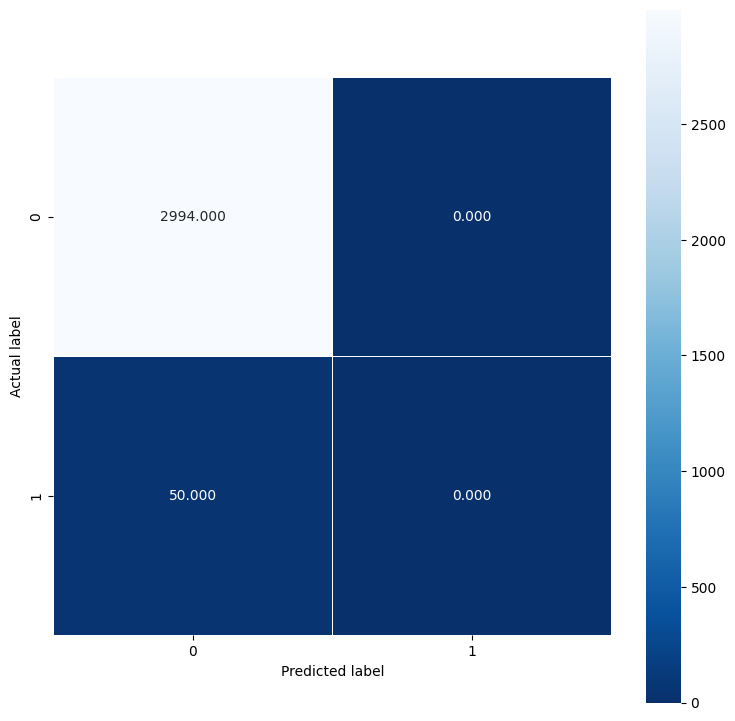

In [28]:
from sklearn.linear_model import LogisticRegression
athletes = sorted(list(dfday['Athlete ID'].unique()))
test_athletes = athletes[len(athletes) - 10:]
X_test = dfday[dfday['Athlete ID'].isin(test_athletes)]
X_train = dfday[~dfday['Athlete ID'].isin(test_athletes)]

y_test = X_test['injury']
y_train = X_train['injury']

X_train = X_train.drop(columns=['injury', 'Date', 'Athlete ID'], errors='ignore')
X_test = X_test.drop(columns=['injury', 'Date', 'Athlete ID'], errors='ignore')


logReg = LogisticRegression()

logReg.fit(X_train,y_train)
predictions = logReg.predict(X_test)
from sklearn import metrics
cm =metrics.confusion_matrix(y_test, predictions)

plt.figure(figsize=(9,9))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');

Obviously, implementing balanced subsets of the data will increase accuracy massively. I'm going to base my implementation of this on that in the script for replicating the paper.

Accuracy: 0.6807
Precision: 0.0286
Recall(most important): 0.5600
F1 Score: 0.0545
F-beta Score (beta=2): 0.1188


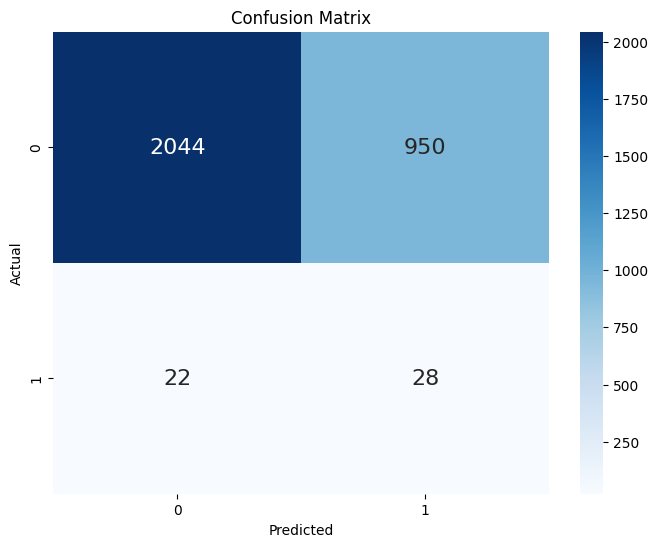

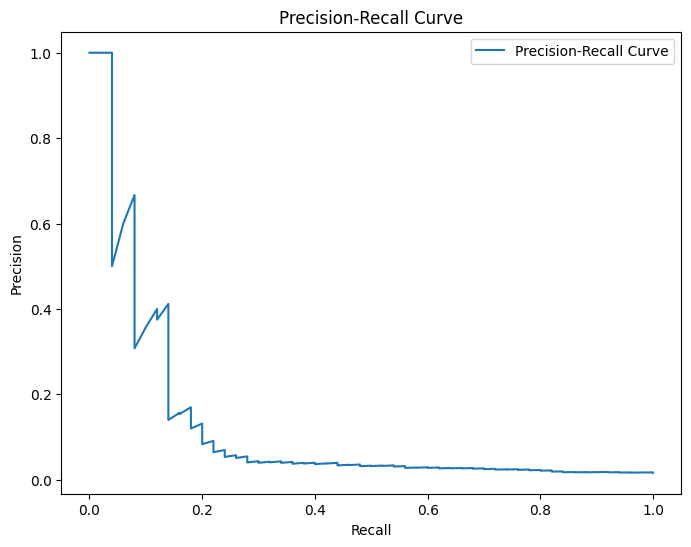

Accuracy: 0.6201
Precision: 0.6365
Recall(most important): 0.5602
F1 Score: 0.5959
F-beta Score (beta=2): 0.5740


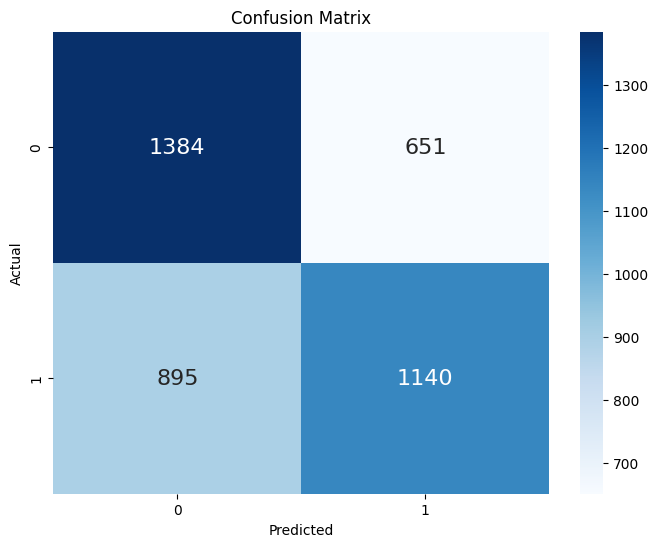

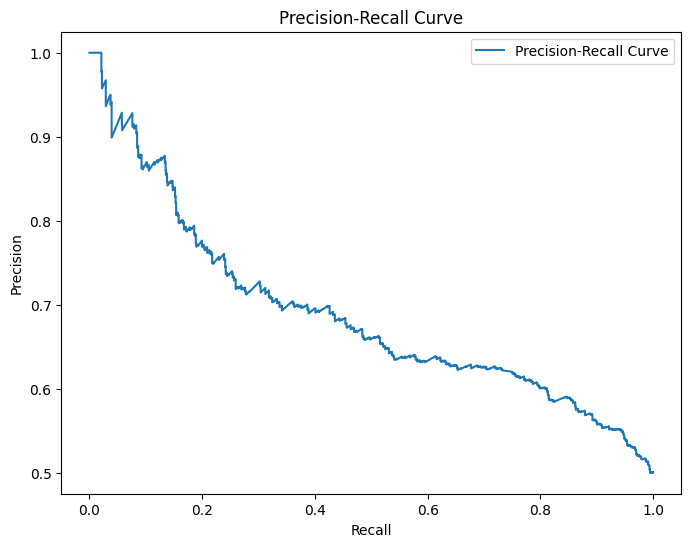

In [29]:
from sklearn.linear_model import LogisticRegression
athletes = sorted(list(dfday['Athlete ID'].unique()))
test_athletes = athletes[len(athletes) - 10:]
X_test_original = dfday[dfday['Athlete ID'].isin(test_athletes)].copy() # Keep a copy for normalization
X_train_original = dfday[~dfday['Athlete ID'].isin(test_athletes)].copy() # Keep a copy


def normalize2(row, mean_df, std_df, athlete_id):
    mu = mean_df.loc[athlete_id]
    su = std_df.loc[athlete_id]
    z = (row - mu)/su
    return z

# Calculate the means and standard deviations of all healthy events per athlete
def getMeanStd(data):
    mean = data[data['injury'] == 0].groupby('Athlete ID').mean()
    std = data[data['injury'] == 0].groupby('Athlete ID').std()
    std.replace(to_replace=0.0, value=0.01, inplace=True)
    return mean, std

def getBalancedSubset(X_train, samplesPerClass):
    healthySet   = pd.DataFrame()
    unhealthySet = pd.DataFrame()
    

    stats = pd.DataFrame(X_train[['Athlete ID','injury']].groupby(['Athlete ID','injury']).size().reset_index(name='counts'))
    stats = pd.DataFrame(stats[['Athlete ID']].groupby(['Athlete ID']).size().reset_index(name='counts'))
    stats.drop(stats[stats['counts'] < 2].index, inplace=True)
    athleteList = stats['Athlete ID'].unique()

    samplesPerAthlete = int(np.floor(samplesPerClass) / len(athleteList))

    for athlete in athleteList:
        if unhealthySet.empty:
            unhealthySet = X_train[(X_train['Athlete ID'] == athlete) & (X_train['injury'] == 0)].sample(samplesPerAthlete, replace=True)
        else:
            unhealthySet = pd.concat([unhealthySet, X_train[(X_train['Athlete ID'] == athlete) & (X_train['injury'] == 0)].sample(samplesPerAthlete,replace=True)], ignore_index=True)
        if healthySet.empty:
            healthySet = X_train[(X_train['Athlete ID'] == athlete) & (X_train['injury'] == 1)].sample(samplesPerAthlete, replace=True)
        else:
            healthySet = pd.concat([healthySet, X_train[(X_train['Athlete ID'] == athlete) & (X_train['injury'] == 1)].sample(samplesPerAthlete,replace=True)], ignore_index=True)


    balancedSet = pd.concat([healthySet, unhealthySet], ignore_index=True)
    return balancedSet

def training_eval(model, y_true, X, y_pred):
    conf_matrix = confusion_matrix(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    fbeta = fbeta_score(y_true, y_pred, beta=2)  # Emphasize recall

    # Print evaluation metrics
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall(most important): {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"F-beta Score (beta=2): {fbeta:.4f}")

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16})
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    # Plot precision-recall curve
    precision_curve, recall_curve, thresholds = precision_recall_curve(y_true, model.predict_proba(X)[:, 1])
    plt.figure(figsize=(8, 6))
    plt.plot(recall_curve, precision_curve, label='Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.show()

X_train_means, X_train_std = getMeanStd(X_train_original)
X_test_means, X_test_std = getMeanStd(X_test_original)



samples_per_class = 2048
X_train_balanced = getBalancedSubset(X_train_original.copy(), samples_per_class)
y_train = X_train_balanced['injury']
y_test = X_test_original['injury']

# 3. Apply normalization to the *balanced training data*
X_train_normalized = X_train_balanced.apply(lambda x: normalize2(x, X_train_means, X_train_std, x['Athlete ID']), axis=1)
X_train_normalized = X_train_normalized.drop(columns=['injury', 'Date', 'Athlete ID'], errors='ignore')

# 4. Apply normalization to the *test data* using the *test* statistics
# this is a source of potential data leakage
X_test_normalized = X_test_original.apply(lambda x: normalize2(x, X_test_means, X_test_std, x['Athlete ID']), axis=1)
X_test_normalized = X_test_normalized.drop(columns=['injury', 'Date', 'Athlete ID'], errors='ignore')

# 5. Train the Logistic Regression model on the normalized training data
logReg = LogisticRegression()
logReg.fit(X_train_normalized, y_train)

# 6. Make predictions on the normalized test data
predictions = logReg.predict(X_test_normalized)


# 7. Evaluate the model (as you have done)
training_eval(logReg, y_test, X_test_normalized, predictions)
training_eval(logReg, y_train, X_train_normalized, logReg.predict(X_train_normalized))


so this shows that, while the model still vastly overpredicts healthy events, as more methods are used to increase the accuracy, the model improves. Next, more complex models will be used and tuned to hopefully capture more interactions between features

## The below code no longer works because User data is no longer stored in memory

In [ ]:
dfday_user =pd.read_csv('../data/processed/df_full.csv')
dfday_user.head(20)
dfday_user.info()

In [ ]:
X_test_normalized.info()

In [ ]:
def normalize_user(row, mean_df, std_df):
    mu = mean_df
    su = std_df
    z = (row - mu)/su
    return z

# Calculate the means and standard deviations of all healthy events per athlete
def getMeanStd_user(data):
    mean = data.mean()
    std = data.std()
    std.replace(to_replace=0.0, value=0.01, inplace=True)
    return mean, std

user_test_means, user_test_std = getMeanStd_user(dfday_user.copy())


# 4. Apply normalization to the *test data* using the *training* statistics
# X_test_normalized = X_test_original.drop(columns=['injury', 'Date', 'Athlete ID'], errors='ignore')
# X_test_normalized = X_test_normalized.apply(lambda x: normalize2(x, X_train_means, X_train_std, x['Athlete ID']), axis=1)
user_normalized = dfday_user.apply(lambda x: normalize_user(x, user_test_means,user_test_std), axis=1)
user_normalized = user_normalized.drop(columns=[ 'Date'], errors='ignore')
predictions = logReg.predict(user_normalized)
predictions

In [ ]:
for i in predictions:
    print(i)

In [ ]:
# create a df of predictions using the date column from dfday_user and the predictions
dfday_user['injury'] = predictions
#view the date column and the predictions column
dfday_user[['Date','injury']].head(20)


In [ ]:
# Plot the predictions over time
plt.figure(figsize=(20,10))
plt.plot(dfday_user['Date'],dfday_user['injury'])

In [ ]:
# get probabilities of the predictions
probs = logReg.predict_proba(user_normalized)[:, 1]
# create a df of probabilities using the date column from dfday_user and the probs
dfday_user['probabilities'] = probs
#view the date column and the probabilities column
dfday_user[['Date','probabilities']].head(20)

In [ ]:
# plot the probabilities over time
plt.figure(figsize=(20,10))
plt.plot(dfday_user['Date'],dfday_user['probabilities'])
# plot the probabilities over time with a rolling mean
plt.figure(figsize=(20,10))
plt.plot(dfday_user['Date'],dfday_user['probabilities'].rolling(window=5).mean())

In [ ]:
#get the probabilities for X_test_normalized
probs = logReg.predict_proba(X_test_normalized)[:, 1]
# create a df of probabilities using the date column from X_test_original and the probs
X_test_original['probabilities'] = probs
#view the date column and the probabilities column for athlete 30
X_test_original[X_test_original['Athlete ID'] == 30][['Date','probabilities']].head(20)


In [ ]:
dfday_user[['Date','probabilities']].head(32)

## assert that weekly and daily datasets can be combined

In [30]:
dfday.columns

Index(['nr. sessions', 'total km', 'km Z3-4', 'km Z5-T1-T2',
       'hours alternative', 'nr. sessions.1', 'total km.1', 'km Z3-4.1',
       'km Z5-T1-T2.1', 'hours alternative.1', 'nr. sessions.2', 'total km.2',
       'km Z3-4.2', 'km Z5-T1-T2.2', 'hours alternative.2', 'nr. sessions.3',
       'total km.3', 'km Z3-4.3', 'km Z5-T1-T2.3', 'hours alternative.3',
       'nr. sessions.4', 'total km.4', 'km Z3-4.4', 'km Z5-T1-T2.4',
       'hours alternative.4', 'nr. sessions.5', 'total km.5', 'km Z3-4.5',
       'km Z5-T1-T2.5', 'hours alternative.5', 'nr. sessions.6', 'total km.6',
       'km Z3-4.6', 'km Z5-T1-T2.6', 'hours alternative.6', 'Athlete ID',
       'injury', 'Date'],
      dtype='object')

In [31]:
dfweek.columns


Index(['nr. sessions', 'nr. rest days', 'total kms', 'max km one day',
       'total km Z3-Z4-Z5-T1-T2',
       'nr. tough sessions (effort in Z5, T1 or T2)', 'total km Z3-4',
       'max km Z3-4 one day', 'total km Z5-T1-T2', 'max km Z5-T1-T2 one day',
       'total hours alternative training', 'nr. sessions.1', 'nr. rest days.1',
       'total kms.1', 'max km one day.1', 'total km Z3-Z4-Z5-T1-T2.1',
       'nr. tough sessions (effort in Z5, T1 or T2).1', 'total km Z3-4.1',
       'max km Z3-4 one day.1', 'total km Z5-T1-T2.1',
       'max km Z5-T1-T2 one day.1', 'total hours alternative training.1',
       'nr. sessions.2', 'nr. rest days.2', 'total kms.2', 'max km one day.2',
       'total km Z3-Z4-Z5-T1-T2.2',
       'nr. tough sessions (effort in Z5, T1 or T2).2', 'total km Z3-4.2',
       'max km Z3-4 one day.2', 'total km Z5-T1-T2.2',
       'max km Z5-T1-T2 one day.2', 'total hours alternative training.2',
       'Athlete ID', 'injury', 'rel total kms week 0_1',
       'rel tot

In [32]:
#check that the the columns for athlete, injuty, and date are the same in both dataframes
# for a subset of the columns
if dfday['Athlete ID','injury', 'Date'] == dfweek['Athlete ID','injury', 'Date']:
    print("The columns are the same")
else:
    print("The columns are not the same")

KeyError: ('Athlete ID', 'injury', 'Date')

In [33]:
dfday['Date']

0           0
1           1
2           2
3           3
4           4
         ... 
42761    2143
42762    2286
42763    2483
42764    2647
42765    2673
Name: Date, Length: 42766, dtype: int64

In [34]:
dfweek['Date']

0           0
1           1
2           2
3           3
4           4
         ... 
42793    2143
42794    2286
42795    2483
42796    2647
42797    2673
Name: Date, Length: 42798, dtype: int64

In [35]:
# what combos of athlete and date are in dfday but not in dfweek
dfday['Athlete ID'].nunique()
dfweek['Athlete ID'].nunique()
dfday['Date'].nunique()
dfweek['Date'].nunique()
# find the athletes that are in dfday but not in dfweek
athletes_in_day_not_week = dfday[~dfday['Athlete ID'].isin(dfweek['Athlete ID'])]
# find the athletes that are in dfweek but not in dfday
athletes_in_week_not_day = dfweek[~dfweek['Athlete ID'].isin(dfday['Athlete ID'])]
print("Athletes in day but not in week:")
print(athletes_in_day_not_week['Athlete ID'].unique())
print("Athletes in week but not in day:")
print(athletes_in_week_not_day['Athlete ID'].unique())
# find the dates that are in dfday but not in dfweek
dates_in_day_not_week = dfday[~dfday['Date'].isin(dfweek['Date'])]
# find the dates that are in dfweek but not in dfday
dates_in_week_not_day = dfweek[~dfweek['Date'].isin(dfday['Date'])]
print("Dates in day but not in week:")
print(dates_in_day_not_week['Date'].unique())
print("Dates in week but not in day:")
print(dates_in_week_not_day['Date'].unique())
# Check if the number of unique athletes and dates are the same in both dataframes
if dfday['Athlete ID'].nunique() == dfweek['Athlete ID'].nunique() and dfday['Date'].nunique() == dfweek['Date'].nunique():
    print("The number of unique athletes and dates are the same in both dataframes")
# but I need to check if the combinations of athletes and dates atre all the same
# Check if the combinations of athletes and dates are the same in both dataframes
if dfday[['Athlete ID', 'Date']].equals(dfweek[['Athlete ID', 'Date']]):
    print("The combinations of athletes and dates are the same in both dataframes")
else:
    print("The combinations of athletes and dates are not the same in both dataframes")
    # find the combinations of athletes and dates that are in dfday but not in dfweek
    combos_in_day_not_week = dfday[~dfday[['Athlete ID', 'Date']].apply(tuple, 1).isin(dfweek[['Athlete ID', 'Date']].apply(tuple, 1))]
    # find the combinations of athletes and dates that are in dfweek but not in dfday
    combos_in_week_not_day = dfweek[~dfweek[['Athlete ID', 'Date']].apply(tuple, 1).isin(dfday[['Athlete ID', 'Date']].apply(tuple, 1))]
    print("Combinations in day but not in week:")
    print(combos_in_day_not_week)
    print("Combinations in week but not in day:")
    print(combos_in_week_not_day)


Athletes in day but not in week:
[]
Athletes in week but not in day:
[]
Dates in day but not in week:
[]
Dates in week but not in day:
[]
The number of unique athletes and dates are the same in both dataframes
The combinations of athletes and dates are not the same in both dataframes
Combinations in day but not in week:
       nr. sessions  total km  km Z3-4  km Z5-T1-T2  hours alternative  \
3159            1.0       8.0      0.0          0.0                0.0   
3160            1.0       2.0      0.0          0.0                0.0   
3161            1.0       1.0      0.0          0.0                0.0   
3162            1.0       0.0      0.0          0.0                0.0   
3163            0.0       0.0      0.0          0.0                0.0   
...             ...       ...      ...          ...                ...   
42519           2.0       5.0      0.0          0.0                0.0   
42520           2.0      12.8      0.0          3.0                1.0   
42630       

In [36]:
# Get combinations of Athlete ID and Date for both datasets
day_combos = set(dfday[['Athlete ID', 'Date']].apply(tuple, axis=1))
week_combos = set(dfweek[['Athlete ID', 'Date']].apply(tuple, axis=1))

# Find combos in dfday but not in dfweek
combos_in_day_not_week = day_combos - week_combos

# Find combos in dfweek but not in dfday
combos_in_week_not_day = week_combos - day_combos

# Display the results
print("Combinations in day but not in week:")
print(combos_in_day_not_week)
print(len(combos_in_day_not_week), "combinations found")

print("Combinations in week but not in day:")
print(combos_in_week_not_day)
print(len(combos_in_week_not_day), "combinations found")

Combinations in day but not in week:
{(63, 1636), (66, 1900), (40, 267), (66, 1845), (66, 1820), (66, 1902), (66, 1856), (66, 1749), (66, 1822), (45, 1207), (66, 1904), (66, 1858), (66, 1751), (66, 1815), (66, 1824), (66, 1833), (35, 268), (66, 1897), (66, 1906), (5, 117), (63, 1645), (66, 1744), (66, 1817), (66, 1899), (66, 1844), (5, 110), (63, 1638), (5, 119), (66, 1746), (66, 1819), (9, 1175), (66, 1901), (5, 112), (63, 1640), (66, 1748), (66, 1812), (66, 1821), (63, 1633), (66, 1903), (5, 114), (63, 1642), (66, 1741), (66, 1860), (66, 1750), (66, 1869), (66, 1814), (66, 1823), (5, 107), (63, 1635), (5, 116), (63, 1644), (66, 1743), (66, 1816), (66, 1825), (5, 109), (63, 1637), (5, 118), (39, 269), (66, 1855), (66, 1745), (66, 1928), (66, 1818), (5, 111), (63, 1639), (45, 1206), (66, 1857), (66, 1747), (52, 991), (69, 2093), (63, 1632), (5, 113), (63, 1641), (66, 1905), (66, 1859), (66, 1813), (5, 106), (63, 1634), (5, 115), (63, 1643), (66, 1898), (66, 1843), (66, 1742), (66, 1861

In [37]:
# Filter the non-overlapping rows
non_overlap_day = dfday[dfday[['Athlete ID', 'Date']].apply(tuple, axis=1).isin(combos_in_day_not_week)]
non_overlap_week = dfweek[dfweek[['Athlete ID', 'Date']].apply(tuple, axis=1).isin(combos_in_week_not_day)]

# Calculate proportions of injury = 1
day_injury_proportion = dfday['injury'].mean()
week_injury_proportion = dfweek['injury'].mean()
non_overlap_day_injury_proportion = non_overlap_day['injury'].mean()
non_overlap_week_injury_proportion = non_overlap_week['injury'].mean()

# Print results
print(f"Proportion of injury = 1 in dfday: {day_injury_proportion:.4f}")
print(f"Proportion of injury = 1 in dfweek: {week_injury_proportion:.4f}")
print(f"Proportion of injury = 1 in non-overlapping combos (day): {non_overlap_day_injury_proportion:.4f}")
print(f"Proportion of injury = 1 in non-overlapping combos (week): {non_overlap_week_injury_proportion:.4f}")

Proportion of injury = 1 in dfday: 0.0136
Proportion of injury = 1 in dfweek: 0.0134
Proportion of injury = 1 in non-overlapping combos (day): 0.0930
Proportion of injury = 1 in non-overlapping combos (week): 0.0000


In [38]:
#number of non_overlap_day rows with injury = 1 
print(f"Number of non-overlapping rows in dfday with injury = 1: {non_overlap_day[non_overlap_day['injury'] == 1].shape[0]}")
# number of rows in dfday with injury = 1
print(f"Number of non-overlapping rows in dfday with injury = 1: {dfday[dfday['injury'] == 1].shape[0]}")

Number of non-overlapping rows in dfday with injury = 1: 8
Number of non-overlapping rows in dfday with injury = 1: 583


so I guess this doesn't really help, but it should definitely be within tolerance for everything

In [39]:
# Add prefixes to columns in dfday and dfweek, excluding the joining columns
dfday_prefixed = dfday.rename(columns=lambda col: f"D-{col}" if col not in ['Athlete ID', 'Date', 'injury'] else col)
dfweek_prefixed = dfweek.rename(columns=lambda col: f"W-{col}" if col not in ['Athlete ID', 'Date', 'injury'] else col)

# Perform an inner join on Athlete ID, Date, and injury
merged_df = pd.merge(dfday_prefixed, dfweek_prefixed, on=['Athlete ID', 'Date', 'injury'], how='inner')

# Display the merged dataset
merged_df.head()

,D-nr. sessions,D-total km,D-km Z3-4,D-km Z5-T1-T2,D-hours alternative,D-nr. sessions.1,D-total km.1,D-km Z3-4.1,D-km Z5-T1-T2.1,D-hours alternative.1,...,W-total km Z3-Z4-Z5-T1-T2.2,"W-nr. tough sessions (effort in Z5, T1 or T2).2",W-total km Z3-4.2,W-max km Z3-4 one day.2,W-total km Z5-T1-T2.2,W-max km Z5-T1-T2 one day.2,W-total hours alternative training.2,W-rel total kms week 0_1,W-rel total kms week 0_2,W-rel total kms week 1_2
0,1.0,5.8,0.0,0.6,0.00,0.0,0.0,0.0,0.0,0.00,...,3.9,0.0,3.2,3.2,0.0,0.0,0.0,0.718447,1.378882,1.919255
1,0.0,0.0,0.0,0.0,0.00,1.0,0.0,0.0,0.0,0.00,...,5.0,0.0,3.2,3.2,0.0,0.0,0.0,0.683544,1.018868,1.490566
2,1.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,...,5.0,0.0,3.2,3.2,0.0,0.0,0.0,0.683544,1.018868,1.490566
3,0.0,0.0,0.0,0.0,0.00,1.0,0.0,0.0,0.0,1.08,...,5.0,0.0,3.2,3.2,0.0,0.0,0.0,0.683544,1.018868,1.490566
4,1.0,0.0,0.0,0.0,1.08,1.0,16.4,10.0,0.0,0.00,...,10.7,0.0,9.6,6.4,0.0,0.0,0.0,2.202247,1.361111,0.618056


In [40]:
merged_df.columns

Index(['D-nr. sessions', 'D-total km', 'D-km Z3-4', 'D-km Z5-T1-T2',
       'D-hours alternative', 'D-nr. sessions.1', 'D-total km.1',
       'D-km Z3-4.1', 'D-km Z5-T1-T2.1', 'D-hours alternative.1',
       'D-nr. sessions.2', 'D-total km.2', 'D-km Z3-4.2', 'D-km Z5-T1-T2.2',
       'D-hours alternative.2', 'D-nr. sessions.3', 'D-total km.3',
       'D-km Z3-4.3', 'D-km Z5-T1-T2.3', 'D-hours alternative.3',
       'D-nr. sessions.4', 'D-total km.4', 'D-km Z3-4.4', 'D-km Z5-T1-T2.4',
       'D-hours alternative.4', 'D-nr. sessions.5', 'D-total km.5',
       'D-km Z3-4.5', 'D-km Z5-T1-T2.5', 'D-hours alternative.5',
       'D-nr. sessions.6', 'D-total km.6', 'D-km Z3-4.6', 'D-km Z5-T1-T2.6',
       'D-hours alternative.6', 'Athlete ID', 'injury', 'Date',
       'W-nr. sessions', 'W-nr. rest days', 'W-total kms', 'W-max km one day',
       'W-total km Z3-Z4-Z5-T1-T2',
       'W-nr. tough sessions (effort in Z5, T1 or T2)', 'W-total km Z3-4',
       'W-max km Z3-4 one day', 'W-total km Z5

In [41]:
# to ensure that everything is in order, select all columns related to total kms, either by week or by day, so I can compare them
# specifically if 'total km. or 'total kms' is in the column name
total_km_columns = [col for col in merged_df.columns if 'D-total km' in col or 'total kms' in col]
# show the subset of the dataset with the total km columns
total_km_subset = merged_df[['Athlete ID', 'Date', 'injury'] + total_km_columns]
# Display the total km subset
total_km_subset.head(20)

,Athlete ID,Date,injury,D-total km,D-total km.1,D-total km.2,D-total km.3,D-total km.4,D-total km.5,D-total km.6,W-total kms,W-total kms.1,W-total kms.2,W-rel total kms week 0_1,W-rel total kms week 0_2,W-rel total kms week 1_2
0,0,0,0,5.8,0.0,0.0,0.0,0.0,16.4,0.0,22.2,30.9,16.1,0.718447,1.378882,1.919255
1,0,1,0,0.0,0.0,0.0,0.0,16.4,0.0,5.2,21.6,31.6,21.2,0.683544,1.018868,1.490566
2,0,2,0,0.0,0.0,0.0,16.4,0.0,5.2,0.0,21.6,31.6,21.2,0.683544,1.018868,1.490566
3,0,3,0,0.0,0.0,16.4,0.0,5.2,0.0,0.0,21.6,31.6,21.2,0.683544,1.018868,1.490566
4,0,4,0,0.0,16.4,0.0,5.2,0.0,0.0,17.6,39.2,17.8,28.8,2.202247,1.361111,0.618056
5,0,5,0,16.4,0.0,5.2,0.0,0.0,17.6,0.0,39.2,17.8,28.8,2.202247,1.361111,0.618056
6,0,6,0,0.0,5.2,0.0,0.0,17.6,0.0,10.5,33.3,22.2,30.9,1.500000,1.077670,0.718447
7,0,7,0,5.2,0.0,0.0,17.6,0.0,10.5,0.0,33.3,22.2,30.9,1.500000,1.077670,0.718447
8,0,8,0,0.0,0.0,17.6,0.0,10.5,0.0,4.8,32.9,21.6,31.6,1.523148,1.041139,0.683544
9,0,9,0,0.0,17.6,0.0,10.5,0.0,4.8,0.0,32.9,21.6,31.6,1.523148,1.041139,0.683544


In [42]:
dfweek.head(21)

,nr. sessions,nr. rest days,total kms,max km one day,total km Z3-Z4-Z5-T1-T2,"nr. tough sessions (effort in Z5, T1 or T2)",total km Z3-4,max km Z3-4 one day,total km Z5-T1-T2,max km Z5-T1-T2 one day,...,max km Z3-4 one day.2,total km Z5-T1-T2.2,max km Z5-T1-T2 one day.2,total hours alternative training.2,Athlete ID,injury,rel total kms week 0_1,rel total kms week 0_2,rel total kms week 1_2,Date
0,5.0,2.0,22.2,16.4,11.8,1.0,10.0,10.0,0.6,0.6,...,3.2,0.0,0.0,0.00,0,0,0.718447,1.378882,1.919255,0
1,5.0,2.0,21.6,16.4,11.7,1.0,10.0,10.0,0.5,0.5,...,3.2,0.0,0.0,0.00,0,0,0.683544,1.018868,1.490566,1
2,5.0,2.0,21.6,16.4,11.7,1.0,10.0,10.0,0.5,0.5,...,3.2,0.0,0.0,0.00,0,0,0.683544,1.018868,1.490566,2
3,5.0,2.0,21.6,16.4,11.7,1.0,10.0,10.0,0.5,0.5,...,3.2,0.0,0.0,0.00,0,0,0.683544,1.018868,1.490566,3
4,6.0,1.0,39.2,17.6,18.9,1.0,17.2,10.0,0.5,0.5,...,6.4,0.0,0.0,0.00,0,0,2.202247,1.361111,0.618056,4
5,6.0,1.0,39.2,17.6,18.9,1.0,17.2,10.0,0.5,0.5,...,6.4,0.0,0.0,1.08,0,0,2.202247,1.361111,0.618056,5
6,6.0,1.0,33.3,17.6,15.4,1.0,13.7,7.2,0.5,0.5,...,6.4,0.0,0.0,1.08,0,0,1.500000,1.077670,0.718447,6
7,5.0,2.0,33.3,17.6,15.4,1.0,13.7,7.2,0.5,0.5,...,6.4,0.0,0.0,2.08,0,0,1.500000,1.077670,0.718447,7
8,5.0,2.0,32.9,17.6,15.5,0.0,14.3,7.2,0.0,0.0,...,6.4,0.6,0.6,2.08,0,0,1.523148,1.041139,0.683544,8
9,5.0,2.0,32.9,17.6,15.5,0.0,14.3,7.2,0.0,0.0,...,6.4,0.6,0.6,2.08,0,0,1.523148,1.041139,0.683544,9


In [43]:
# to reduce columns, I will remove all columns sstarting with W- and not ending with 1 or 2
cols_to_drop = [col for col in merged_df.columns if col.startswith('W-') and not (col.endswith('.1') or col.endswith('.2'))]
no_overdf = merged_df.drop(columns=cols_to_drop)
no_overdf.columns

Index(['D-nr. sessions', 'D-total km', 'D-km Z3-4', 'D-km Z5-T1-T2',
       'D-hours alternative', 'D-nr. sessions.1', 'D-total km.1',
       'D-km Z3-4.1', 'D-km Z5-T1-T2.1', 'D-hours alternative.1',
       'D-nr. sessions.2', 'D-total km.2', 'D-km Z3-4.2', 'D-km Z5-T1-T2.2',
       'D-hours alternative.2', 'D-nr. sessions.3', 'D-total km.3',
       'D-km Z3-4.3', 'D-km Z5-T1-T2.3', 'D-hours alternative.3',
       'D-nr. sessions.4', 'D-total km.4', 'D-km Z3-4.4', 'D-km Z5-T1-T2.4',
       'D-hours alternative.4', 'D-nr. sessions.5', 'D-total km.5',
       'D-km Z3-4.5', 'D-km Z5-T1-T2.5', 'D-hours alternative.5',
       'D-nr. sessions.6', 'D-total km.6', 'D-km Z3-4.6', 'D-km Z5-T1-T2.6',
       'D-hours alternative.6', 'Athlete ID', 'injury', 'Date',
       'W-nr. sessions.1', 'W-nr. rest days.1', 'W-total kms.1',
       'W-max km one day.1', 'W-total km Z3-Z4-Z5-T1-T2.1',
       'W-nr. tough sessions (effort in Z5, T1 or T2).1', 'W-total km Z3-4.1',
       'W-max km Z3-4 one day.1'

### I've dropped the relative increase columns here!

In [44]:
no_overdf.drop(columns=['W-nr. tough sessions (effort in Z5, T1 or T2).1','W-nr. tough sessions (effort in Z5, T1 or T2).2'], inplace=True)
no_overdf.drop(columns=[], inplace=True)

### Feature combination
I think a really valuable thing to follow here would be the Acute to chronic workload ratio(ACWR), as it would really allow to capture the more broad trends, how they interact, and theoretically it's a big driver of injury. 

the implications of ACWR is that comparing aggregated factors for say the past week to the aggregated factors for the past 3 weeks would be beneficial. so I would very likely use as columns the aggregated factors for those time windows without comparison as well as including the ratios themselves for a variety of stuff

I think that a lot of the quantities can be treated under one of three regimes, intensity, volume, and frequency. voulume and frequency for running are somewhat related, but in some cases it will matter. quantities like number of kms per run might give a lot of info but I think something like max info would be good as well. I think I could probably summarise intensity pretty well by just saying what fraction of kms in a aggregate period were Z3+ on average, allowing me to collate at least 10 columns. 

one question is what do I want that distinguishes between week 2 and week three vs what I want that is for all three weeks

'D-nr. sessions.6',
'D-total km.6', 
'D-km Z3-4.6', 
'D-km Z5-T1-T2.6',
'D-hours alternative.6', 
'W-nr. sessions.1', 
'W-nr. rest days.1', 
'W-total kms.1',
'W-max km one day.1', 
'W-total km Z3-Z4-Z5-T1-T2.1',
'W-nr. tough sessions (effort in Z5, T1 or T2).1', 
'W-total km Z3-4.1',
'W-max km Z3-4 one day.1',
'W-total km Z5-T1-T2.1',
'W-max km Z5-T1-T2 one day.1', 
'W-total hours alternative training.1',

to

'D-nr. sessions.6',
'D-total km.6', 
'D-km Z3+
'D-hours alternative.6', only use aggregated versions of this
'W-nr. sessions.1', 
'W-nr. rest days.1', 
'W-total kms.1',
'W-max km one day.1', 
'W-total km Z3-Z4-Z5-T1-T2.1',
'W-max km Z3+ one day.1 
'W-total hours alternative training.1',


D1-total km
D1-km z3-4
D1-km z5
D2-3 nr.sessions
D2-3 total km
D2-3 km z3-4
D2-3 km z5
D4-7 nr.sessions
D4-7 total km
D4-7 km z3
'W-max km one day.1', 
'W-total km Z3-Z4-Z5-T1-T2.1',
'W-max km Z3+ one day.1 
'W-max km one day.2', 
'W-total km Z3-Z4-Z5-T1-T2.2',
'W-max km Z3+ one day.2
5day/3W tot km ratio
5day/3W proportion in Z3+
5day/3W nsessions
5day/3W total hours alt
ACWR = 5day totkm + totkm x proportion / 3week totkm +totkm x proportion
the only consideration for average ratios to ratios is scaling, closer to 1 should be easier to handle

I could use the distinction between z34 and z5 only in aggregates?
I could use the nrest days? would also be in the ratios.

In [45]:
no_overdf.columns

Index(['D-nr. sessions', 'D-total km', 'D-km Z3-4', 'D-km Z5-T1-T2',
       'D-hours alternative', 'D-nr. sessions.1', 'D-total km.1',
       'D-km Z3-4.1', 'D-km Z5-T1-T2.1', 'D-hours alternative.1',
       'D-nr. sessions.2', 'D-total km.2', 'D-km Z3-4.2', 'D-km Z5-T1-T2.2',
       'D-hours alternative.2', 'D-nr. sessions.3', 'D-total km.3',
       'D-km Z3-4.3', 'D-km Z5-T1-T2.3', 'D-hours alternative.3',
       'D-nr. sessions.4', 'D-total km.4', 'D-km Z3-4.4', 'D-km Z5-T1-T2.4',
       'D-hours alternative.4', 'D-nr. sessions.5', 'D-total km.5',
       'D-km Z3-4.5', 'D-km Z5-T1-T2.5', 'D-hours alternative.5',
       'D-nr. sessions.6', 'D-total km.6', 'D-km Z3-4.6', 'D-km Z5-T1-T2.6',
       'D-hours alternative.6', 'Athlete ID', 'injury', 'Date',
       'W-nr. sessions.1', 'W-nr. rest days.1', 'W-total kms.1',
       'W-max km one day.1', 'W-total km Z3-Z4-Z5-T1-T2.1',
       'W-total km Z3-4.1', 'W-max km Z3-4 one day.1', 'W-total km Z5-T1-T2.1',
       'W-max km Z5-T1-T2 one d

In [46]:
combodf = pd.DataFrame()
combodf['Athlete ID'] = no_overdf['Athlete ID']
combodf['Date'] = no_overdf['Date']
combodf['injury'] = no_overdf['injury']
combodf['Day1 total km'] = no_overdf['D-total km']
combodf['Day1 km z3+'] = no_overdf['D-km Z3-4'] + no_overdf['D-km Z5-T1-T2']
combodf['Day1 km z5'] = no_overdf['D-km Z5-T1-T2']
combodf['Day2-3 nr.sessions'] = no_overdf['D-nr. sessions.1'] + no_overdf['D-nr. sessions.2']
combodf['Day2-3 total km'] = no_overdf['D-total km.1'] + no_overdf['D-total km.2']
combodf['Day2-3 km z3+'] = no_overdf['D-km Z3-4.1'] + no_overdf['D-km Z3-4.2'] + no_overdf['D-km Z5-T1-T2.1'] + no_overdf['D-km Z5-T1-T2.2']
combodf['Day2-3 km z5'] = no_overdf['D-km Z5-T1-T2.1'] + no_overdf['D-km Z5-T1-T2.2']
combodf['Day4-7 nr.sessions'] = no_overdf['D-nr. sessions.3'] + no_overdf['D-nr. sessions.4'] + no_overdf['D-nr. sessions.5'] + no_overdf['D-nr. sessions.6']
combodf['Day4-7 total km'] = no_overdf['D-total km.3'] + no_overdf['D-total km.4'] + no_overdf['D-total km.5'] + no_overdf['D-total km.6']
combodf['Day4-7 km z3+'] = no_overdf['D-km Z3-4.3'] + no_overdf['D-km Z3-4.4'] + no_overdf['D-km Z3-4.5'] + no_overdf['D-km Z3-4.6'] + no_overdf['D-km Z5-T1-T2.3'] + no_overdf['D-km Z5-T1-T2.4'] + no_overdf['D-km Z5-T1-T2.5'] + no_overdf['D-km Z5-T1-T2.6']
combodf['Week1 max km one day'] = no_overdf['W-max km one day.1']
combodf['Week1 total km z3+'] = no_overdf['W-total km Z3-Z4-Z5-T1-T2.1']
combodf['Week1 max km Z3+ one day'] = no_overdf['W-max km Z3-4 one day.1']+ no_overdf['W-max km Z5-T1-T2 one day.1']
combodf['Week2 max km one day'] = no_overdf['W-max km one day.2']
combodf['Week2 total km z3+'] = no_overdf['W-total km Z3-Z4-Z5-T1-T2.2']
combodf['Week2 max km Z3+ one day'] = no_overdf['W-max km Z3-4 one day.2']+ no_overdf['W-max km Z5-T1-T2 one day.2']

combodf.head(20)

,Athlete ID,Date,injury,Day1 total km,Day1 km z3+,Day1 km z5,Day2-3 nr.sessions,Day2-3 total km,Day2-3 km z3+,Day2-3 km z5,Day4-7 nr.sessions,Day4-7 total km,Day4-7 km z3+,Week1 max km one day,Week1 total km z3+,Week1 max km Z3+ one day,Week2 max km one day,Week2 total km z3+,Week2 max km Z3+ one day
0,0,0,0,5.8,0.6,0.6,1.0,0.0,0.0,0.0,3.0,16.4,10.0,13.8,13.5,6.4,9.9,3.9,3.2
1,0,1,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,4.0,21.6,10.5,13.8,14.2,7.0,9.9,5.0,3.2
2,0,2,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,21.6,10.5,13.8,14.2,7.0,9.9,5.0,3.2
3,0,3,0,0.0,0.0,0.0,2.0,16.4,10.0,0.0,3.0,5.2,0.5,13.8,14.2,7.0,9.9,5.0,3.2
4,0,4,0,0.0,0.0,0.0,2.0,16.4,10.0,0.0,3.0,22.8,7.7,12.0,7.8,6.6,13.8,10.7,6.4
5,0,5,0,16.4,10.0,0.0,2.0,5.2,0.5,0.5,3.0,17.6,7.2,12.0,7.8,6.6,13.8,10.7,6.4
6,0,6,0,0.0,0.0,0.0,1.0,5.2,0.5,0.5,4.0,28.1,13.7,16.4,11.8,10.6,13.8,13.5,6.4
7,0,7,0,5.2,0.5,0.5,1.0,0.0,0.0,0.0,3.0,28.1,13.7,16.4,11.8,10.6,13.8,13.5,6.4
8,0,8,0,0.0,0.0,0.0,2.0,17.6,7.2,0.0,3.0,15.3,7.1,16.4,11.7,10.5,13.8,14.2,7.0
9,0,9,0,0.0,0.0,0.0,2.0,17.6,7.2,0.0,2.0,15.3,7.1,16.4,11.7,10.5,13.8,14.2,7.0


In [47]:
combodf.shape

(42680, 19)

In [48]:
day5totkm = no_overdf['D-total km'] + no_overdf['D-total km.1'] + no_overdf['D-total km.2'] + no_overdf['D-total km.3'] + no_overdf['D-total km.4']
week3totkm =  0.00001 + day5totkm + no_overdf['D-total km.5'] + no_overdf['D-total km.6'] + no_overdf['W-total kms.1'] + no_overdf['W-total kms.2']
combodf['5day/3W tot km ratio'] = (day5totkm / week3totkm).round(3)

day5kmz3plus = no_overdf['D-km Z3-4'] + no_overdf['D-km Z3-4.1'] + no_overdf['D-km Z3-4.2'] + no_overdf['D-km Z3-4.3'] + no_overdf['D-km Z3-4.4']+ no_overdf['D-km Z5-T1-T2'] + no_overdf['D-km Z5-T1-T2.1'] + no_overdf['D-km Z5-T1-T2.2'] + no_overdf['D-km Z5-T1-T2.3'] + no_overdf['D-km Z5-T1-T2.4']
week3kmz3plus = 0.00001 + day5kmz3plus + no_overdf['D-km Z3-4.5'] + no_overdf['D-km Z3-4.6'] + no_overdf['D-km Z5-T1-T2.5'] + no_overdf['D-km Z5-T1-T2.6'] + no_overdf['W-total km Z3-Z4-Z5-T1-T2.1'] + no_overdf['W-total km Z3-Z4-Z5-T1-T2.2']
#day5propz3plus = (day5kmz3plus / day5totkm).round(3)
#week3propz3plus = (week3kmz3plus / week3totkm).round(3)
#combodf['5day/3W proportion km z3+'] = day5propz3plus / week3propz3plus.round()

# Calculate with zero handling
day5propz3plus = np.where(day5totkm != 0, (day5kmz3plus / day5totkm).round(3), 0)
week3propz3plus = np.where(week3totkm != 0, (week3kmz3plus / week3totkm).round(3), 0)

# Calculate the ratio and handle zero division
combodf['5day/3W proportion km z3+'] = np.where(
    week3propz3plus != 0, (day5propz3plus / week3propz3plus).round(3), 0
)

day5nsessions = no_overdf['D-nr. sessions'] + no_overdf['D-nr. sessions.1'] + no_overdf['D-nr. sessions.2'] + no_overdf['D-nr. sessions.3'] + no_overdf['D-nr. sessions.4']
week3nsessions = 0.00001 + day5nsessions + no_overdf['D-nr. sessions.5'] + no_overdf['D-nr. sessions.6'] + no_overdf['W-nr. sessions.1'] + no_overdf['W-nr. sessions.2']
combodf['5day/3W nr. sessions ratio'] = (day5nsessions / week3nsessions).round(3)

day5hoursalt = no_overdf['D-hours alternative'] + no_overdf['D-hours alternative.1'] + no_overdf['D-hours alternative.2'] + no_overdf['D-hours alternative.3'] + no_overdf['D-hours alternative.4']
week3hoursalt = 0.00001 + day5hoursalt + no_overdf['D-hours alternative.5'] + no_overdf['D-hours alternative.6'] + no_overdf['W-total hours alternative training.1'] + no_overdf['W-total hours alternative training.2']
combodf['5day/3W hours alternative training ratio'] = (day5hoursalt / week3hoursalt).round(3)

C:\Users\milo\AppData\Local\Temp\ipykernel_28732\3949861243.py:17: RuntimeWarning: invalid value encountered in divide
  week3propz3plus != 0, (day5propz3plus / week3propz3plus).round(3), 0


In [49]:
combodf['ACWR'] = ((day5totkm + (day5propz3plus* day5totkm))*4)/ (week3totkm + (week3propz3plus * week3totkm))

In [50]:
combodf.head(20)

,Athlete ID,Date,injury,Day1 total km,Day1 km z3+,Day1 km z5,Day2-3 nr.sessions,Day2-3 total km,Day2-3 km z3+,Day2-3 km z5,...,Week1 total km z3+,Week1 max km Z3+ one day,Week2 max km one day,Week2 total km z3+,Week2 max km Z3+ one day,5day/3W tot km ratio,5day/3W proportion km z3+,5day/3W nr. sessions ratio,5day/3W hours alternative training ratio,ACWR
0,0,0,0,5.8,0.6,0.6,1.0,0.0,0.0,0.0,...,13.5,6.4,9.9,3.9,3.2,0.084,0.254,0.214,0.260,0.263197
1,0,1,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,14.2,7.0,9.9,5.0,3.2,0.220,1.529,0.200,0.260,1.014703
2,0,2,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,14.2,7.0,9.9,5.0,3.2,0.220,1.529,0.286,0.500,1.014703
3,0,3,0,0.0,0.0,0.0,2.0,16.4,10.0,0.0,...,14.2,7.0,9.9,5.0,3.2,0.290,1.218,0.267,0.500,1.233508
4,0,4,0,0.0,0.0,0.0,2.0,16.4,10.0,0.0,...,7.8,6.6,13.8,10.7,6.4,0.252,1.152,0.267,0.500,1.052315
5,0,5,0,16.4,10.0,0.0,2.0,5.2,0.5,0.5,...,7.8,6.6,13.8,10.7,6.4,0.252,1.152,0.250,0.194,1.052315
6,0,6,0,0.0,0.0,0.0,1.0,5.2,0.5,0.5,...,11.8,10.6,13.8,13.5,6.4,0.264,0.740,0.250,0.194,0.969343
7,0,7,0,5.2,0.5,0.5,1.0,0.0,0.0,0.0,...,11.8,10.6,13.8,13.5,6.4,0.264,0.740,0.250,0.194,0.969343
8,0,8,0,0.0,0.0,0.0,2.0,17.6,7.2,0.0,...,11.7,10.5,13.8,14.2,7.0,0.326,1.045,0.250,0.194,1.324146
9,0,9,0,0.0,0.0,0.0,2.0,17.6,7.2,0.0,...,11.7,10.5,13.8,14.2,7.0,0.326,1.045,0.250,0.194,1.324146


In [51]:
combodf.shape

(42680, 24)

### Check correlations

In [52]:
checkforhighcorr(combodf,0.7)

['Week2 max km one day correlates with Week1 max km one day value '
 '0.7401217326525938',
 'Week1 max km Z3+ one day correlates with Week1 total km z3+ value '
 '0.8917950441136868',
 'Week1 total km z3+ correlates with Week1 max km Z3+ one day value '
 '0.8917950441136869',
 'Week1 max km one day correlates with Week2 max km one day value '
 '0.7401217326525938',
 'Week2 max km Z3+ one day correlates with Week2 total km z3+ value '
 '0.8902278525081115',
 'Week2 total km z3+ correlates with Week2 max km Z3+ one day value '
 '0.8902278525081115',
 'ACWR correlates with 5day/3W tot km ratio value 0.9892330321419854',
 '5day/3W tot km ratio correlates with ACWR value 0.9892330321419855']


In [53]:
# check for correlation with the injury column vs all other columns
corr_with_injury = combodf.corr()['injury'].drop('injury')
# Sort the correlations in descending order
sorted_corr = corr_with_injury.abs().sort_values(ascending=False)
# Display the top 10 features with the highest correlation with injury
print("Top 10 features correlated with injury:")
print(sorted_corr.head(23))

Top 10 features correlated with injury:
Date                                        0.029525
Day4-7 nr.sessions                          0.026409
Day4-7 km z3+                               0.022532
5day/3W proportion km z3+                   0.021523
5day/3W nr. sessions ratio                  0.021242
Day1 km z5                                  0.020160
Day2-3 nr.sessions                          0.019778
Week1 total km z3+                          0.016607
Day1 total km                               0.015460
5day/3W tot km ratio                        0.015040
ACWR                                        0.014955
Day1 km z3+                                 0.013954
Day2-3 km z3+                               0.013685
Week1 max km Z3+ one day                    0.012657
Week1 max km one day                        0.011617
Day4-7 total km                             0.008841
Day2-3 km z5                                0.006953
5day/3W hours alternative training ratio    0.006555
Week2 

## basic model implementation

In [54]:
from sklearn.linear_model import LogisticRegression
athletes = sorted(list(combodf['Athlete ID'].unique()))
test_athletes = athletes[len(athletes) - 10:]
X_test = combodf[combodf['Athlete ID'].isin(test_athletes)]
X_train = combodf[~combodf['Athlete ID'].isin(test_athletes)]

y_test = X_test['injury']
y_train = X_train['injury']

X_train = X_train.drop(columns=['injury', 'Date', 'Athlete ID'], errors='ignore')
X_test = X_test.drop(columns=['injury', 'Date', 'Athlete ID'], errors='ignore')


logReg = LogisticRegression()



c:\Users\milo\Desktop\publicprojectsMilo\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


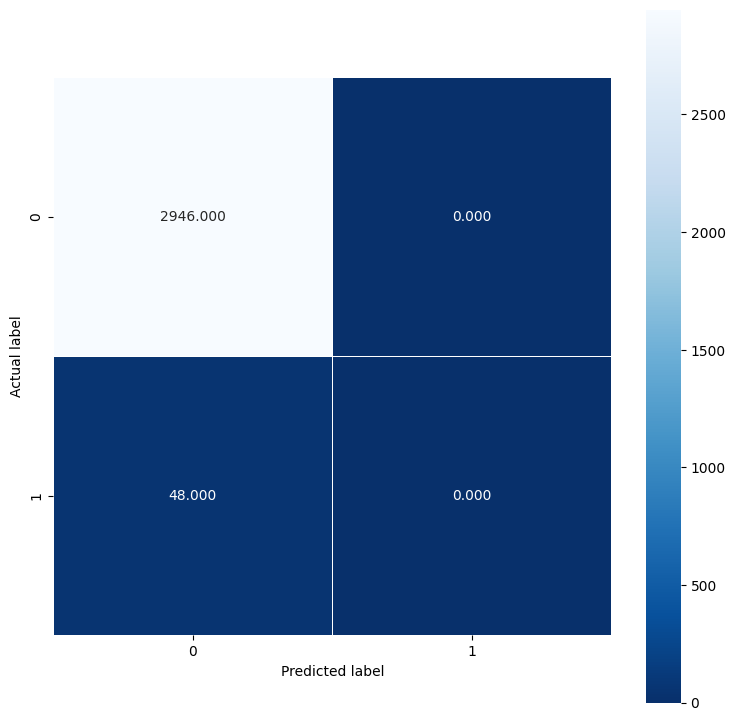

In [55]:
logReg.fit(X_train,y_train)
predictions = logReg.predict(X_test)
from sklearn import metrics
cm =metrics.confusion_matrix(y_test, predictions)

plt.figure(figsize=(9,9))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');

In [ ]:
# save to csv
combodf.to_csv('../data/combodf.csv', index=False)

D2-3 nr.sessions
D2-3 total km
D2-3 km z3-4
D2-3 km z5
D4-7 nr.sessions
D4-7 total km
D4-7 km z3
'W-max km one day.1', 
'W-total km Z3-Z4-Z5-T1-T2.1',
'W-max km Z3+ one day.1 
'W-max km one day.2', 
'W-total km Z3-Z4-Z5-T1-T2.2',
'W-max km Z3+ one day.2
5day/3W tot km ratio
5day/3W proportion in Z3+
5day/3W nsessions
5day/3W total hours alt
ACWR = 5day totkm + totkm x proportion / 3week totkm +totkm x proportion